# Demand Forecasting Model using PySpark

## Project Description
This project aims to predict e-commerce product demand using PySpark to improve supply chain efficiency, reduce stockouts, and optimize inventory management. The model leverages historical sales data and advanced analytics to generate accurate demand forecasts.

## Objectives
* Predict future product demand
* Identify seasonal trends and purchasing patterns
* Optimize inventory and supply chain decisions
* Improve business efficiency and reduce costs

## 1. Data Engineer (Ingestion & Storage)

**Responsibilities:**
* Read data
* Perform data cleaning and preprocessing using PySpark
* Store data in distributed systems (HDFS / Data Lake)

### Initialize Spark Session and Generate Synthetic Data

In [ ]:
import os
import sys
from pathlib import Path
from pyspark.sql import functions as F

# Ensure local Spark in the dev container
os.environ["SPARK_MASTER"] = "local[*]"

# Allow importing helper.py from the pipeline folder
pipeline_dir = "/pipeline/pipeline"
if pipeline_dir not in sys.path:
    sys.path.append(pipeline_dir)

from helper import get_spark, upload_local_csv_to_minio, upload_hdfs_path_to_minio

# Local data paths
BASE_PATH = "/pipeline/data"
RAW_PATH = f"{BASE_PATH}/Amazon.csv"
LOCAL_OUTPUT_PATH = f"{BASE_PATH}/cleaned_data/amazon_cleaned.csv"
os.makedirs(os.path.dirname(LOCAL_OUTPUT_PATH), exist_ok=True)

# Optional HDFS/MinIO settings
HDFS_URI = os.getenv("CORE_CONF_fs_defaultFS", "hdfs://namenode:9000")
MINIO_SILVER_BUCKET = os.getenv("MINIO_SILVER_BUCKET", "silver")
MINIO_SILVER_PREFIX = os.getenv("MINIO_SILVER_PREFIX", "demand_forecasting/cleaned_data")
MINIO_GOLD_BUCKET = os.getenv("MINIO_GOLD_BUCKET", "gold")
MINIO_GOLD_MODEL_PREFIX = os.getenv(
    "MINIO_GOLD_MODEL_PREFIX", "demand_forecasting/models/linear_regression_model"
 )

# Initialize Spark Session (local)
spark = get_spark("DemandForecastingLocal")
spark.sparkContext.setLogLevel("WARN")

# Load Amazon.csv from the local workspace volume
raw_uri = f"file://{Path(RAW_PATH).resolve()}"
spark_df = spark.read.csv(raw_uri, header=True, inferSchema=True)

# Basic cleaning aligned to phase1_data_engineer.py
cols_to_drop = [c for c in ["CustomerID"] if c in spark_df.columns]
spark_df_cleaned = (
    spark_df.drop(*cols_to_drop)
    .dropDuplicates(["OrderID"])
.dropna(subset=["OrderID", "OrderDate", "TotalAmount"])
)
spark_df_cleaned = (
    spark_df_cleaned
    .withColumn("OrderDate", F.to_date("OrderDate", "yyyy-MM-dd"))
    .withColumn("TotalAmount", F.abs(F.col("TotalAmount")))
    .withColumn("Quantity", F.when(F.col("Quantity") < 1, 1).otherwise(F.col("Quantity")))
    .fillna({"Discount": 0.0, "Tax": 0.0, "ShippingCost": 0.0})
)

# IQR outlier filter on TotalAmount
quantiles = spark_df_cleaned.approxQuantile("TotalAmount", [0.25, 0.75], 0.05)
if len(quantiles) == 2:
    q1, q3 = quantiles
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    spark_df_cleaned = spark_df_cleaned.filter(
        (F.col("TotalAmount") >= lower_bound) & (F.col("TotalAmount") <= upper_bound)
    )

# Save cleaned data locally for later phases
spark_df_cleaned.toPandas().to_csv(LOCAL_OUTPUT_PATH, index=False)
print(f"Saved cleaned data to: {LOCAL_OUTPUT_PATH}")

spark_df_cleaned.printSchema()
spark_df_cleaned.show(5)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/01 19:32:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/01 19:32:13 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Saved cleaned data to: /pipeline/data/cleaned_data/amazon_cleaned.csv
root
 |-- OrderID: string (nullable = true)
 |-- OrderDate: date (nullable = true)
 |-- CustomerName: string (nullable = true)
 |-- ProductID: string (nullable = true)
 |-- ProductName: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Brand: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- Discount: double (nullable = false)
 |-- Tax: double (nullable = false)
 |-- ShippingCost: double (nullable = false)
 |-- TotalAmount: double (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- OrderStatus: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- SellerID: string (nullable = true)



+----------+----------+-------------+---------+-------------------+-----------------+----------+--------+---------+--------+------+------------+-----------+-------------+-----------+----------+-----+-------------+---------+
|   OrderID| OrderDate| CustomerName|ProductID|        ProductName|         Category|     Brand|Quantity|UnitPrice|Discount|   Tax|ShippingCost|TotalAmount|PaymentMethod|OrderStatus|      City|State|      Country| SellerID|
+----------+----------+-------------+---------+-------------------+-----------------+----------+--------+---------+--------+------+------------+-----------+-------------+-----------+----------+-----+-------------+---------+
|ORD0000001|2023-01-31|Vihaan Sharma|   P00014|         Drone Mini|            Books| BrightLux|       3|   106.59|     0.0|   0.0|        0.09|     319.86|   Debit Card|  Delivered|Washington|   DC|        India|SELL01967|
|ORD0000002|2023-12-30|  Pooja Kumar|   P00040|         Microphone|   Home & Kitchen|UrbanStyle|       1

In [ ]:
# Local Spark connectivity smoke test
print(f"Spark master: {spark.sparkContext.master}")
print(f"Spark app name: {spark.sparkContext.appName}")
print(f"Raw data path: {RAW_PATH}")
print(f"Cleaned data path: {LOCAL_OUTPUT_PATH}")

print(f"Rows in cleaned data: {spark_df_cleaned.count()}")
spark_df_cleaned.select("OrderID", "OrderDate", "TotalAmount").show(5)

Spark master: local[*]
Spark app name: DemandForecastingLocal
Raw data path: /pipeline/data/Amazon.csv
Cleaned data path: /pipeline/data/cleaned_data/amazon_cleaned.csv
Rows in cleaned data: 96607
+----------+----------+-----------+
|   OrderID| OrderDate|TotalAmount|
+----------+----------+-----------+
|ORD0000030|2022-08-13|    1185.13|
|ORD0000190|2023-12-01|    1162.38|
|ORD0000544|2021-09-27|     437.08|
|ORD0000820|2022-12-17|    1852.32|
|ORD0000969|2021-11-15|     912.94|
+----------+----------+-----------+
only showing top 5 rows



### Data Cleaning and Preprocessing

In [ ]:
# Normalize types and ensure numeric defaults
spark_df_cleaned = spark_df_cleaned.withColumn("OrderDate", F.to_date(F.col("OrderDate")))

numeric_defaults = {
    "Quantity": 0,
    "UnitPrice": 0.0,
    "Discount": 0.0,
    "Tax": 0.0,
    "ShippingCost": 0.0,
    "TotalAmount": 0.0,
}
spark_df_cleaned = spark_df_cleaned.fillna(numeric_defaults)

# Standardize a sales column for downstream EDA
spark_df_cleaned = spark_df_cleaned.withColumn("total_sales", F.col("TotalAmount"))

spark_df_cleaned.printSchema()
spark_df_cleaned.show(5)

print(
    "Missing TotalAmount after fill:",
    spark_df_cleaned.filter(F.col("TotalAmount").isNull()).count(),
)

root
 |-- OrderID: string (nullable = true)
 |-- OrderDate: date (nullable = true)
 |-- CustomerName: string (nullable = true)
 |-- ProductID: string (nullable = true)
 |-- ProductName: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Brand: string (nullable = true)
 |-- Quantity: integer (nullable = false)
 |-- UnitPrice: double (nullable = false)
 |-- Discount: double (nullable = false)
 |-- Tax: double (nullable = false)
 |-- ShippingCost: double (nullable = false)
 |-- TotalAmount: double (nullable = false)
 |-- PaymentMethod: string (nullable = true)
 |-- OrderStatus: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- SellerID: string (nullable = true)
 |-- total_sales: double (nullable = false)



+----------+----------+-------------+---------+-------------------+-----------------+----------+--------+---------+--------+------+------------+-----------+-------------+-----------+----------+-----+-------------+---------+-----------+
|   OrderID| OrderDate| CustomerName|ProductID|        ProductName|         Category|     Brand|Quantity|UnitPrice|Discount|   Tax|ShippingCost|TotalAmount|PaymentMethod|OrderStatus|      City|State|      Country| SellerID|total_sales|
+----------+----------+-------------+---------+-------------------+-----------------+----------+--------+---------+--------+------+------------+-----------+-------------+-----------+----------+-----+-------------+---------+-----------+
|ORD0000001|2023-01-31|Vihaan Sharma|   P00014|         Drone Mini|            Books| BrightLux|       3|   106.59|     0.0|   0.0|        0.09|     319.86|   Debit Card|  Delivered|Washington|   DC|        India|SELL01967|     319.86|
|ORD0000002|2023-12-30|  Pooja Kumar|   P00040|         

In [ ]:
# Persist cleaned data to HDFS when available
cleaned_data_hdfs_path = f"{HDFS_URI}/user/data-engineer/demand_forecasting/cleaned_data"
hdfs_write_ok = False
try:
    spark_df_cleaned.write.mode("overwrite").parquet(cleaned_data_hdfs_path)
    hdfs_write_ok = True
    print(f"Saved cleaned data to: {cleaned_data_hdfs_path}")
except Exception as exc:
    print(f"HDFS write skipped: {exc}")

# Read back from HDFS to verify (if write succeeded)
if hdfs_write_ok:
    spark_df_cleaned_hdfs = spark.read.parquet(cleaned_data_hdfs_path)
    print("Rows loaded back from HDFS:", spark_df_cleaned_hdfs.count())
    spark_df_cleaned_hdfs.show(5)

# Upload local CSV to MinIO (optional)
try:
    upload_local_csv_to_minio(
        local_csv_path=LOCAL_OUTPUT_PATH,
        minio_bucket=MINIO_SILVER_BUCKET,
        minio_prefix=MINIO_SILVER_PREFIX,
        app_name="DemandForecasting-LocalCSV-To-MinIO-Silver",
    )
except Exception as exc:
    print(f"MinIO upload skipped: {exc}")

# Upload HDFS parquet to MinIO (optional)
if hdfs_write_ok:
    try:
        upload_hdfs_path_to_minio(
            hdfs_path=cleaned_data_hdfs_path,
            minio_bucket=MINIO_SILVER_BUCKET,
            minio_prefix=MINIO_SILVER_PREFIX,
            app_name="DemandForecasting-HDFS-To-MinIO-Silver",
        )
    except Exception as exc:
        print(f"MinIO HDFS upload skipped: {exc}")

Saved cleaned data to: hdfs://namenode:9000/user/data-engineer/demand_forecasting/cleaned_data
Rows loaded back from HDFS: 96607
+----------+----------+-------------+---------+----------------+-----------------+--------+--------+---------+--------+------+------------+-----------+-------------+-----------+-----------+-----+-------------+---------+-----------+
|   OrderID| OrderDate| CustomerName|ProductID|     ProductName|         Category|   Brand|Quantity|UnitPrice|Discount|   Tax|ShippingCost|TotalAmount|PaymentMethod|OrderStatus|       City|State|      Country| SellerID|total_sales|
+----------+----------+-------------+---------+----------------+-----------------+--------+--------+---------+--------+------+------------+-----------+-------------+-----------+-----------+-----+-------------+---------+-----------+
|ORD0000006|2022-12-31| Karan Sharma|   P00023|    Cookware Set|            Books|ReadMore|       4|   449.73|     0.0|215.87|        2.74|    2017.53|          UPI|  Delivere

26/05/01 19:32:32 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Rows read from local CSV: 96607
Writing temporary parquet locally: file:///tmp/local_csv_export_qr3cpbky/export


Uploaded 10 files to MinIO bucket 'silver' under prefix 'demand_forecasting/cleaned_data'
Reading from HDFS: hdfs://namenode:9000/user/data-engineer/demand_forecasting/cleaned_data
Rows read from HDFS: 96607
Writing temporary parquet locally: file:///tmp/hdfs_export_srlu0v30/export


Uploaded 10 files to MinIO bucket 'silver' under prefix 'demand_forecasting/cleaned_data'


## 2. Data Analyst (Exploration & Insights)

**Responsibilities:**
* Perform Exploratory Data Analysis (EDA)
* Analyze trends and patterns in sales data
* Generate insights and visualizations

### Basic Statistics and Schema

In [ ]:
import os
import sys
from pathlib import Path
from pyspark.sql import functions as F

# Ensure Spark is active before running EDA
pipeline_dir = "/pipeline/pipeline"
if pipeline_dir not in sys.path:
    sys.path.append(pipeline_dir)
from helper import get_spark

BASE_PATH = "/pipeline/data"
LOCAL_OUTPUT_PATH = f"{BASE_PATH}/cleaned_data/amazon_cleaned.csv"

spark_active = True
try:
    _ = spark.sparkContext.applicationId
except Exception:
    spark_active = False

if not spark_active:
    spark = get_spark("DemandForecastingLocal-EDA")
    spark.sparkContext.setLogLevel("WARN")
    local_uri = f"file://{Path(LOCAL_OUTPUT_PATH).resolve()}"
    spark_df_cleaned = spark.read.csv(local_uri, header=True, inferSchema=True)
    spark_df_cleaned = spark_df_cleaned.withColumn("total_sales", F.col("TotalAmount"))

spark_df_cleaned.describe().show()

# Convert to Pandas for easier visualization (for small datasets)
# For large datasets, use PySpark's DataFrame operations or distributed visualization tools
pd_df_for_eda = spark_df_cleaned.toPandas()

+-------+----------+------------+---------+-----------+------------+------+------------------+-----------------+-------------------+-----------------+-----------------+-----------------+-------------+-----------+----------+-----+-------------+---------+-----------------+
|summary|   OrderID|CustomerName|ProductID|ProductName|    Category| Brand|          Quantity|        UnitPrice|           Discount|              Tax|     ShippingCost|      TotalAmount|PaymentMethod|OrderStatus|      City|State|      Country| SellerID|      total_sales|
+-------+----------+------------+---------+-----------+------------+------+------------------+-----------------+-------------------+-----------------+-----------------+-----------------+-------------+-----------+----------+-----+-------------+---------+-----------------+
|  count|     96607|       96607|    96607|      96607|       96607| 96607|             96607|            96607|              96607|            96607|            96607|            9660

### Sales Trends Over Time

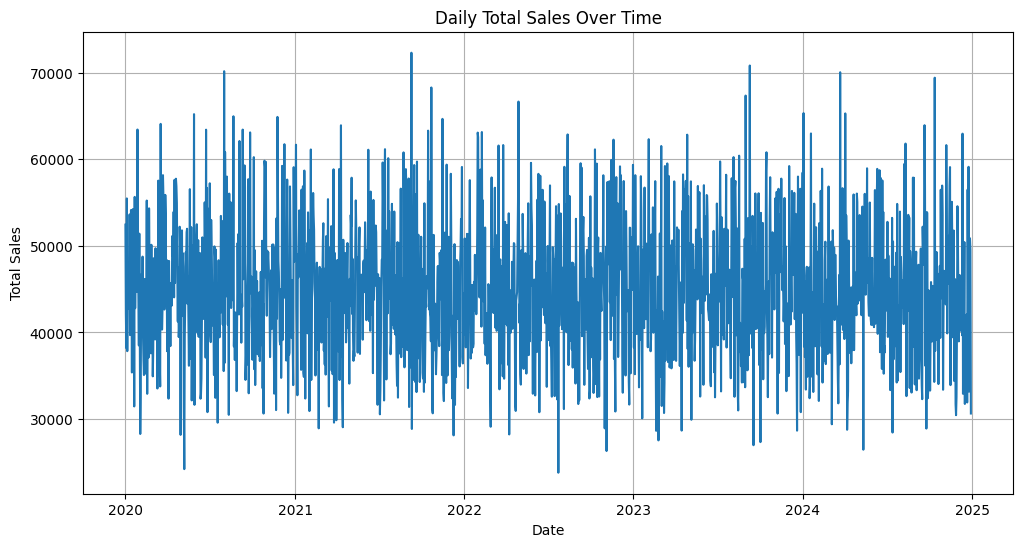

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate daily sales
daily_sales = pd_df_for_eda.groupby("OrderDate")["total_sales"].sum().reset_index()
daily_sales = daily_sales.sort_values("OrderDate")

plt.figure(figsize=(12, 6))
sns.lineplot(x="OrderDate", y="total_sales", data=daily_sales)
plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

### Sales by Product and Store

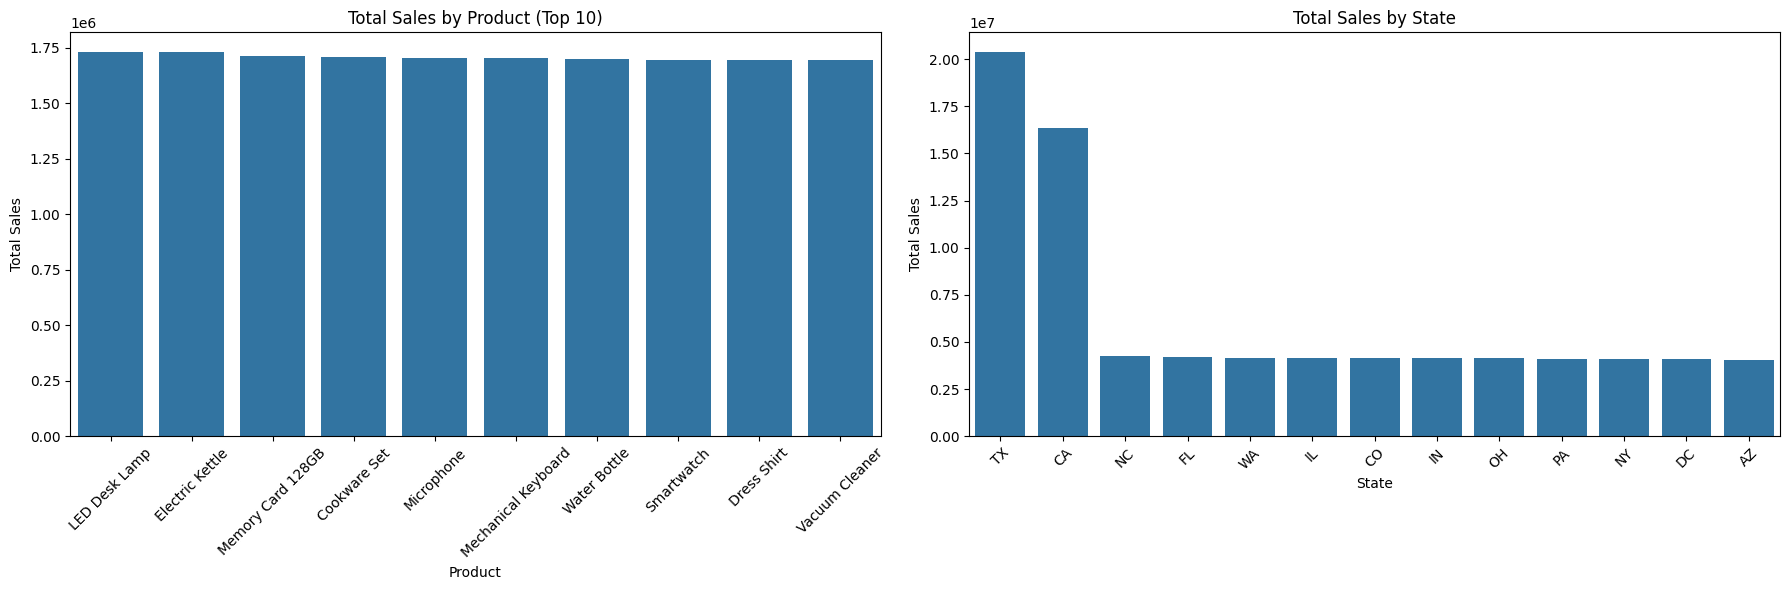

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sales by Product
product_sales = (
    pd_df_for_eda.groupby("ProductName")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
sns.barplot(x="ProductName", y="total_sales", data=product_sales, ax=axes[0])
axes[0].set_title("Total Sales by Product (Top 10)")
axes[0].set_xlabel("Product")
axes[0].set_ylabel("Total Sales")
axes[0].tick_params(axis="x", rotation=45)

# Sales by State
state_sales = (
    pd_df_for_eda.groupby("State")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
sns.barplot(x="State", y="total_sales", data=state_sales, ax=axes[1])
axes[1].set_title("Total Sales by State")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Total Sales")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

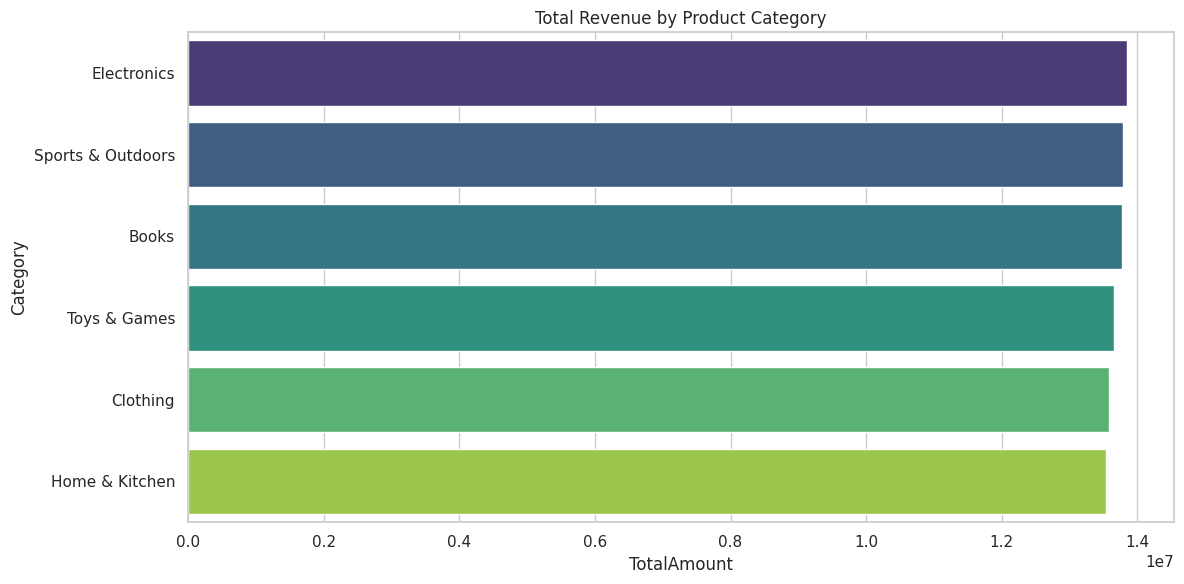

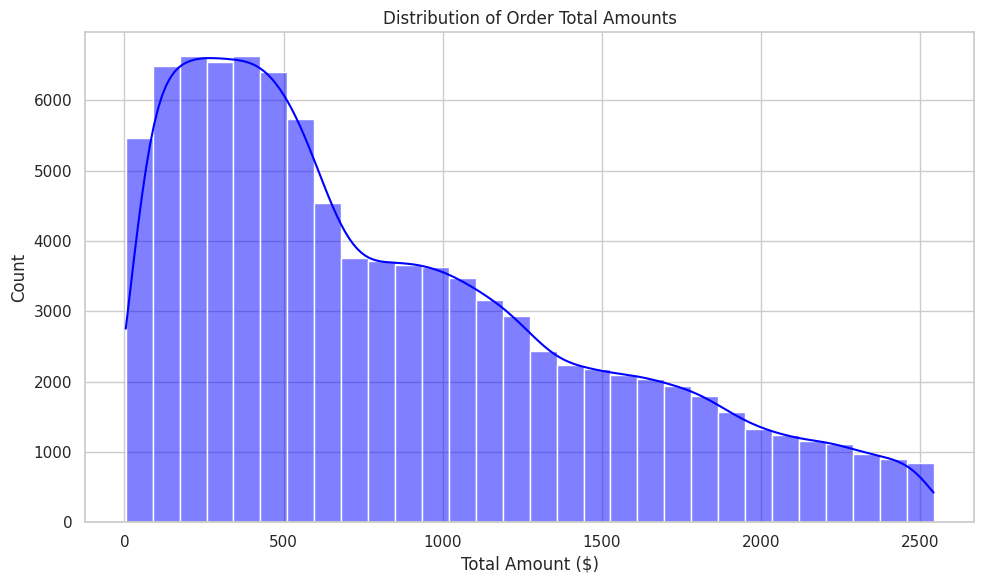

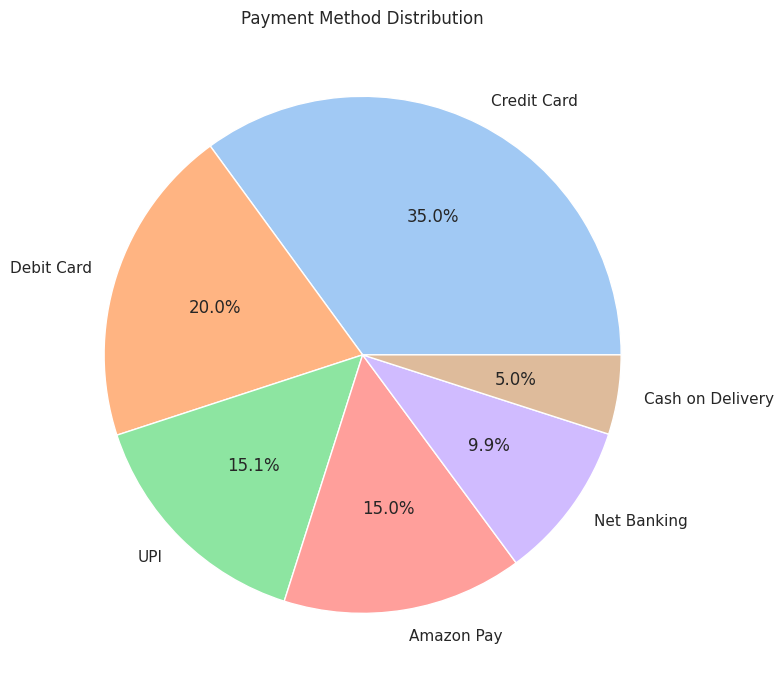

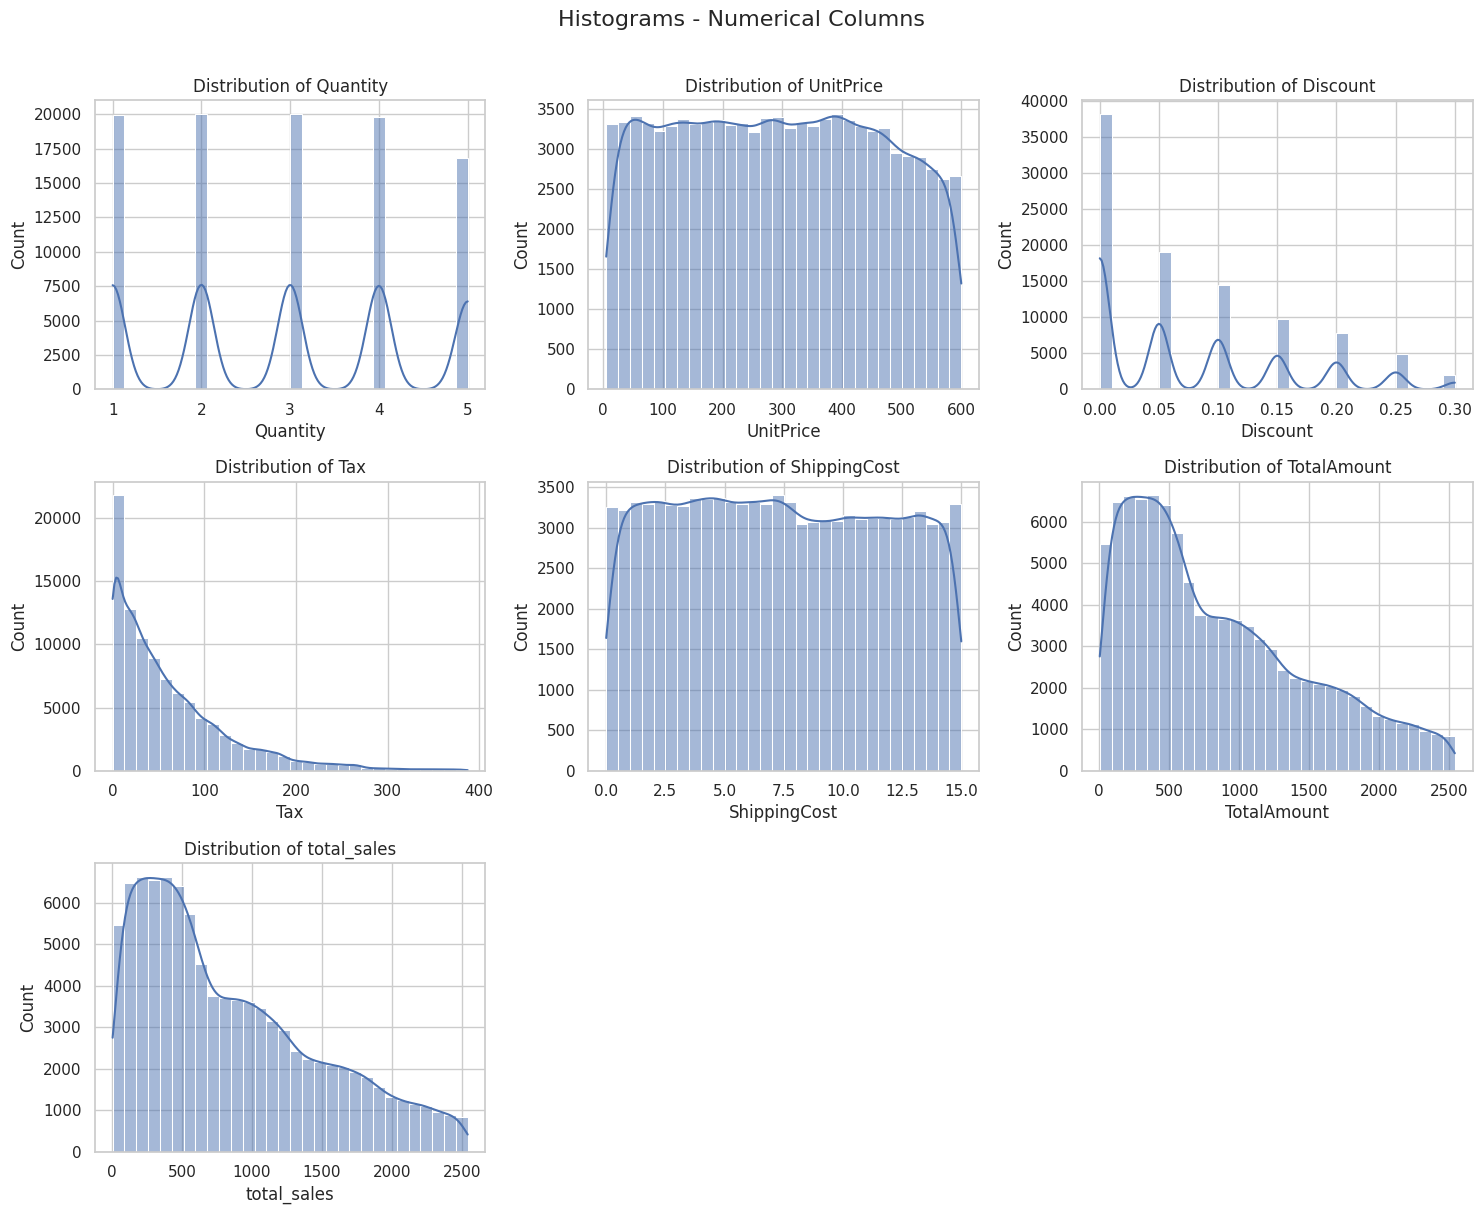

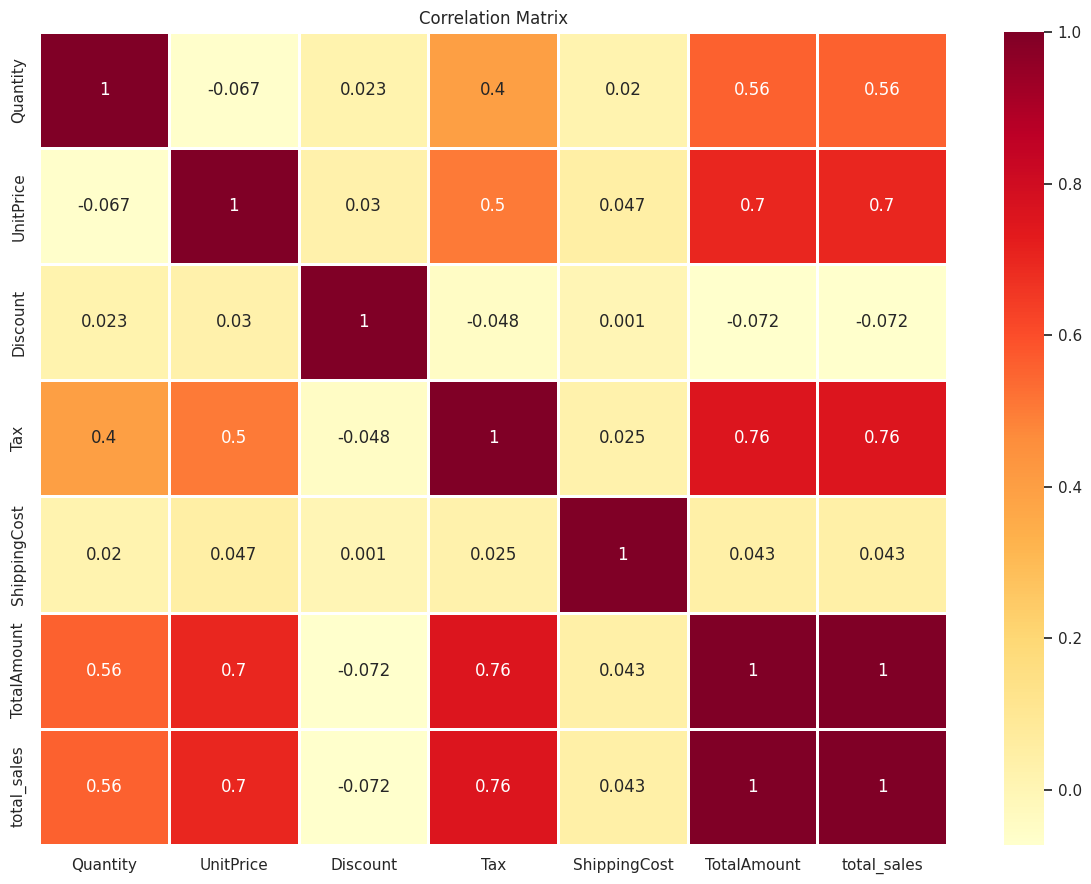

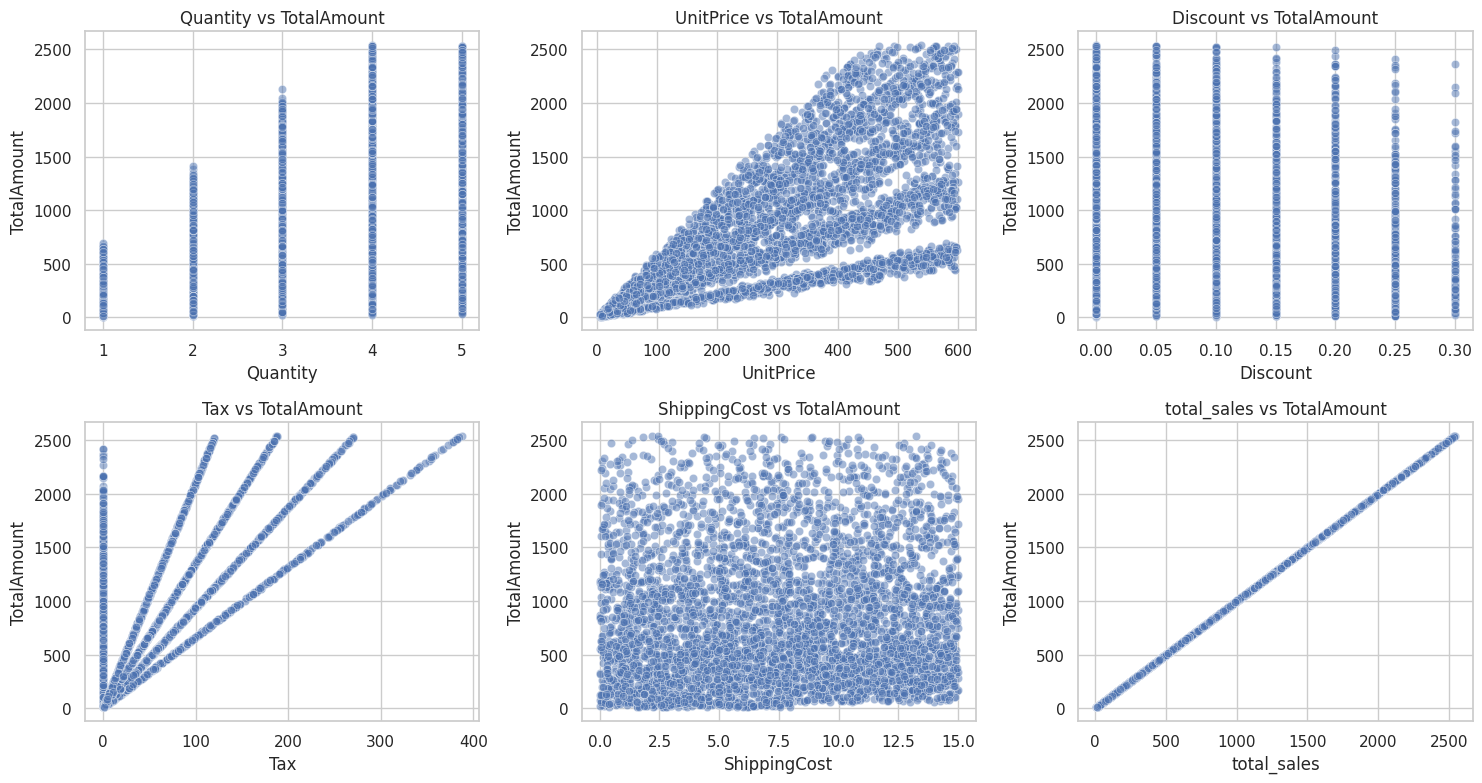

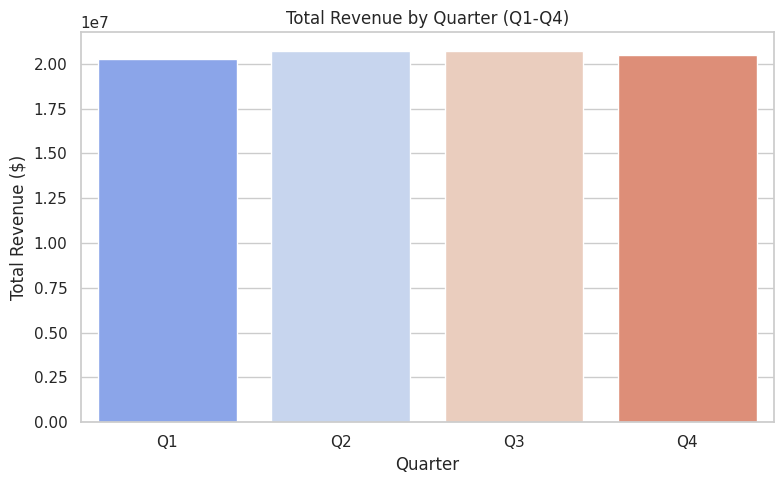

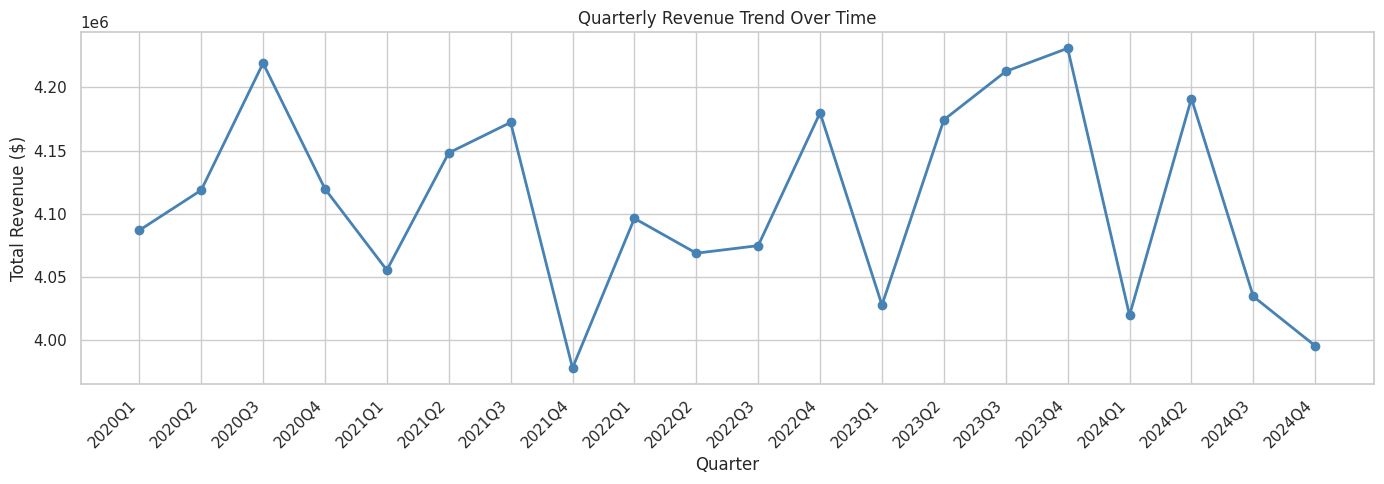

Saved charts to: /pipeline/data/analysis/figures


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = f"{BASE_PATH}/analysis/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd_df_for_eda.copy()
df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")
df = df.dropna(subset=["OrderDate"])
sns.set_theme(style="whitegrid")

num_cols = df.select_dtypes(include=["number"]).columns.to_list()
cat_cols = df.select_dtypes(include=["object"]).drop(columns=["ProductName"], errors="ignore").columns.to_list()

# Chart 01: Revenue by Category
cat_pdf = (
    df.groupby("Category", as_index=False)["TotalAmount"]
    .sum()
    .sort_values("TotalAmount", ascending=False)
)
plt.figure(figsize=(12, 6))
sns.barplot(data=cat_pdf, x="TotalAmount", y="Category", hue="Category", palette="viridis", legend=False)
plt.title("Total Revenue by Product Category")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_revenue_by_category.png", bbox_inches="tight")
plt.show()
plt.close()

# Chart 02: Sales Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["TotalAmount"], bins=30, kde=True, color="blue")
plt.title("Distribution of Order Total Amounts")
plt.xlabel("Total Amount ($)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_sales_distribution.png", bbox_inches="tight")
plt.show()
plt.close()

# Chart 03: Payment Method Pie
plt.figure(figsize=(8, 8))
df["PaymentMethod"].value_counts().plot.pie(autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_payment_methods.png", bbox_inches="tight")
plt.show()
plt.close()

# Chart 04: Histograms for All Numerical Columns
columns = 3
rows = (len(num_cols) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 4 * rows))
axes = axes.flatten()
plt.suptitle("Histograms - Numerical Columns", fontsize=16, y=1.01)
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
for ax in axes[len(num_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_histograms_numerical.png", bbox_inches="tight")
plt.show()
plt.close()

# Chart 05: Countplots for Categorical Columns
# columns = 3
# rows = (len(cat_cols) + columns - 1) // columns
# fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 4 * rows))
# axes = axes.flatten()
# plt.suptitle("Countplots - Categorical Columns", fontsize=16, y=1.01)
# for i, col in enumerate(cat_cols):
#     sns.countplot(y=df[col], hue=df[col], ax=axes[i], palette="Set2", legend=False)
#     axes[i].set_title(f"Distribution of {col}")
# for ax in axes[len(cat_cols):]:
#     ax.set_visible(False)
# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/05_countplots_categorical.png", bbox_inches="tight")
# plt.show()
# plt.close()

# Chart 06: Violin Plot - TotalAmount
# plt.figure(figsize=(10, 5))
# sns.violinplot(y=df["TotalAmount"], color="skyblue")
# plt.title("Spread of Total Amount")
# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/06_violin_total_amount.png", bbox_inches="tight")
# plt.show()
# plt.close()

# Chart 07: Correlation Matrix Heatmap
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, linewidth=0.9, cmap="YlOrRd")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_correlation_matrix.png", bbox_inches="tight")
plt.show()
plt.close()

# Chart 08: Scatter Plots vs TotalAmount
x_cols = [col for col in num_cols if col != "TotalAmount"]
y = "TotalAmount"
columns = 3
rows = (len(x_cols) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 4 * rows))
axes = axes.flatten()
sample_df = df.sample(min(4500, len(df)), random_state=42)
for i, x in enumerate(x_cols):
    sns.scatterplot(data=sample_df, x=x, y=y, ax=axes[i], alpha=0.5)
    axes[i].set_title(f"{x} vs {y}")
for ax in axes[len(x_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_scatter_vs_total_amount.png", bbox_inches="tight")
plt.show()
plt.close()

# Chart 09: Revenue by Quarter Bar Chart (Q1-Q4)
df["Quarter"] = "Q" + df["OrderDate"].dt.quarter.astype(str)
quarter_summary_pdf = df.groupby("Quarter", as_index=False)["TotalAmount"].sum().sort_values("Quarter")
plt.figure(figsize=(8, 5))
sns.barplot(data=quarter_summary_pdf, x="Quarter", y="TotalAmount", hue="Quarter", palette="coolwarm", legend=False)
plt.title("Total Revenue by Quarter (Q1-Q4)")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_revenue_by_quarter_bar.png", bbox_inches="tight")
plt.show()
plt.close()

# Chart 10: Quarterly Revenue Trend Over Time Line Chart
df["YearQuarter"] = df["OrderDate"].dt.to_period("Q").astype(str)
quarterly_pdf = df.groupby("YearQuarter", as_index=False)["TotalAmount"].sum().sort_values("YearQuarter")
plt.figure(figsize=(14, 5))
plt.plot(quarterly_pdf["YearQuarter"], quarterly_pdf["TotalAmount"], marker="o", color="steelblue", linewidth=2)
plt.xticks(rotation=45, ha="right")
plt.title("Quarterly Revenue Trend Over Time")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/10_quarterly_revenue_trend.png", bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved charts to: {OUTPUT_DIR}")

### Additional EDA Visualizations (Phase 2)

## 3. Machine Learning Engineer (Model Development)

**Responsibilities:**
* Build and train forecasting models
* Perform feature engineering (lag features, seasonal features)
* Evaluate model performance

**Models Used (Conceptual):**
* Linear Regression
* Random Forest
* Gradient Boosting
* Time Series Models (ARIMA / Prophet)

### Feature Engineering

In [ ]:
from pyspark.sql.functions import dayofmonth, dayofweek, month, year, weekofyear, lag
from pyspark.sql.window import Window

# Aggregate data to daily level for forecasting
daily_agg_df = (
    spark_df_cleaned.groupBy("OrderDate", "ProductID", "State")
    .agg(
        F.sum("Quantity").alias("daily_quantity"),
        F.sum("TotalAmount").alias("daily_total_sales"),
    )
    .withColumnRenamed("OrderDate", "order_date")
)

# Sort by date, product, and state for lag features
window_spec = Window.partitionBy("ProductID", "State").orderBy("order_date")

# Add time-based features
daily_agg_df = (
    daily_agg_df.withColumn("day_of_month", dayofmonth(F.col("order_date")))
    .withColumn("day_of_week", dayofweek(F.col("order_date")))
    .withColumn("month", month(F.col("order_date")))
    .withColumn("year", year(F.col("order_date")))
    .withColumn("week_of_year", weekofyear(F.col("order_date")))
)

# Add lag features (e.g., previous day's quantity)
daily_agg_df = daily_agg_df.withColumn(
    "lag_1_day_qty", lag(F.col("daily_quantity"), 1).over(window_spec)
)

# Fill NaN created by lag features
daily_agg_df = daily_agg_df.fillna(0, subset=["lag_1_day_qty"])

daily_agg_df.show(5)
daily_agg_df.printSchema()

+----------+---------+-----+--------------+-----------------+------------+-----------+-----+----+------------+-------------+
|order_date|ProductID|State|daily_quantity|daily_total_sales|day_of_month|day_of_week|month|year|week_of_year|lag_1_day_qty|
+----------+---------+-----+--------------+-----------------+------------+-----------+-----+----+------------+-------------+
|2020-01-09|   P00001|   CO|             2|           779.54|           9|          5|    1|2020|           2|            0|
|2020-01-23|   P00001|   CO|             1|           407.28|          23|          5|    1|2020|           4|            2|
|2020-01-28|   P00001|   CO|             1|            52.74|          28|          3|    1|2020|           5|            1|
|2020-04-15|   P00001|   CO|             5|          1648.37|          15|          4|    4|2020|          16|            1|
|2020-04-17|   P00001|   CO|             2|           370.21|          17|          6|    4|2020|          16|            5|


### Prepare Data for ML Model

In [ ]:
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# Convert categorical features to numerical using StringIndexer and OneHotEncoder
indexer_product = StringIndexer(inputCol="ProductID", outputCol="product_idx")
indexer_state = StringIndexer(inputCol="State", outputCol="state_idx")

encoder_product = OneHotEncoder(inputCol="product_idx", outputCol="product_vec")
encoder_state = OneHotEncoder(inputCol="state_idx", outputCol="state_vec")

# Define features and label
feature_cols = [
    "day_of_month",
    "day_of_week",
    "month",
    "year",
    "week_of_year",
    "lag_1_day_qty",
    "product_vec",
    "state_vec",
]
label_col = "daily_quantity"

# Assemble features into a single vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Create a pipeline to apply transformations
pipeline = Pipeline(stages=[
    indexer_product,
    indexer_state,
    encoder_product,
    encoder_state,
    assembler,
])

# Fit and transform the data
ml_df = pipeline.fit(daily_agg_df).transform(daily_agg_df)

# Select final features and label
model_data = ml_df.select("features", label_col)
model_data.show(5)

+--------------------+--------------+
|            features|daily_quantity|
+--------------------+--------------+
|(67,[0,1,2,3,4,26...|             2|
|(67,[0,1,2,3,4,5,...|             1|
|(67,[0,1,2,3,4,5,...|             1|
|(67,[0,1,2,3,4,5,...|             5|
|(67,[0,1,2,3,4,5,...|             2|
+--------------------+--------------+
only showing top 5 rows



### Split Data (Train/Test)

In [ ]:
# Split data into training and testing sets
train_data, test_data = model_data.randomSplit([0.8, 0.2], seed=42)

print(f"Training Data Count: {train_data.count()}")
print(f"Testing Data Count: {test_data.count()}")

Training Data Count: 72470


Testing Data Count: 17948


### Build and Train Linear Regression Model

### Evaluate Model Performance

In [ ]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import functions as F

# Ensure Spark is active and data is loaded
pipeline_dir = "/pipeline/pipeline"
if pipeline_dir not in sys.path:
    sys.path.append(pipeline_dir)
from helper import get_spark, build_minio_client

BASE_PATH = "/pipeline/data"
LOCAL_OUTPUT_PATH = f"{BASE_PATH}/cleaned_data/amazon_cleaned.csv"

spark_active = True
try:
    _ = spark.sparkContext.applicationId
except Exception:
    spark_active = False

if not spark_active:
    spark = get_spark("DemandForecastingLocal-ML")
    spark.sparkContext.setLogLevel("WARN")
    local_uri = f"file://{Path(LOCAL_OUTPUT_PATH).resolve()}"
    spark_df_cleaned = spark.read.csv(local_uri, header=True, inferSchema=True)
    spark_df_cleaned = spark_df_cleaned.withColumn("OrderDate", F.to_date(F.col("OrderDate")))
    spark_df_cleaned = spark_df_cleaned.withColumn("total_sales", F.col("TotalAmount"))

def upload_model_dir_to_minio(local_dir: str, bucket: str, prefix: str) -> None:
    client = build_minio_client()
    if not client.bucket_exists(bucket):
        client.make_bucket(bucket)
    for root, _, files in os.walk(local_dir):
        for name in files:
            local_path = os.path.join(root, name)
            rel_path = os.path.relpath(local_path, local_dir).replace(os.sep, "/")
            object_name = f"{prefix}/{rel_path}"
            client.fput_object(bucket, object_name, local_path)

# Feature engineering (Month/DayOfWeek)
df_ml = (
    spark_df_cleaned
    .withColumn("Month", F.month("OrderDate"))
    .withColumn("DayOfWeek", F.dayofweek("OrderDate"))
    .fillna(0)
)

evaluator_rmse = RegressionEvaluator(labelCol="TotalAmount", predictionCol="prediction", metricName="rmse")
evaluator_mse = RegressionEvaluator(labelCol="TotalAmount", predictionCol="prediction", metricName="mse")
evaluator_r2 = RegressionEvaluator(labelCol="TotalAmount", predictionCol="prediction", metricName="r2")

FEATURE_COLS = ["Quantity", "Discount", "Tax", "ShippingCost", "Month", "DayOfWeek"]
assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features")
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")

train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
accuracy_metrics = []

models = {
    "Linear_Regression": LinearRegression(featuresCol="scaledFeatures", labelCol="TotalAmount"),
    "Random_Forest": RandomForestRegressor(featuresCol="scaledFeatures", labelCol="TotalAmount"),
    "Gradient_Boosting": GBTRegressor(featuresCol="scaledFeatures", labelCol="TotalAmount"),
}

MODEL_SAVE_BASE = "/pipeline/data/models"
os.makedirs(MODEL_SAVE_BASE, exist_ok=True)
HDFS_MODEL_BASE = f"{HDFS_URI}/user/data-engineer/demand_forecasting/models"

for name, model_obj in models.items():
    print(f"Training {name}...")
    pipeline = Pipeline(stages=[assembler, scaler, model_obj])
    fit_model = pipeline.fit(train_df)

    local_path = f"{MODEL_SAVE_BASE}/{name}"
    fit_model.write().overwrite().save(local_path)
    print(f"Saved local model: {local_path}")

    hdfs_model_ok = False
    hdfs_path = f"{HDFS_MODEL_BASE}/{name}"
    try:
        fit_model.write().overwrite().save(hdfs_path)
        hdfs_model_ok = True
        print(f"Saved HDFS model: {hdfs_path}")
    except Exception as exc:
        print(f"HDFS model save skipped: {exc}")

    try:
        upload_model_dir_to_minio(
            local_dir=local_path,
            bucket=MINIO_GOLD_BUCKET,
            prefix=f"{MINIO_GOLD_MODEL_PREFIX}/{name}",
        )
    except Exception as exc:
        print(f"MinIO model upload skipped: {exc}")

    preds = fit_model.transform(test_df)
    rmse = evaluator_rmse.evaluate(preds)
    mse = evaluator_mse.evaluate(preds)
    r2 = evaluator_r2.evaluate(preds)
    accuracy_metrics.append({"Model": name, "RMSE": rmse, "MSE": mse, "R2": r2})

# ARIMA (time series)
print("Processing ARIMA...")
ts_data = df_ml.groupBy("OrderDate").agg(F.sum("TotalAmount").alias("Sales")).toPandas()
ts_data["OrderDate"] = pd.to_datetime(ts_data["OrderDate"])
ts_data = ts_data.set_index("OrderDate").sort_index().asfreq("D").fillna(0)

if len(ts_data) > 10:
    from statsmodels.tsa.arima.model import ARIMA
    train_size = int(len(ts_data) * 0.8)
    train_series = ts_data["Sales"].iloc[:train_size]
    test_series = ts_data["Sales"].iloc[train_size:]

    model_arima = ARIMA(train_series, order=(5, 1, 0))
    results_arima = model_arima.fit()
    joblib.dump(results_arima, f"{MODEL_SAVE_BASE}/arima_model.pkl")

    forecast = results_arima.forecast(steps=len(test_series))
    actual = test_series.to_numpy()
    predicted = forecast.to_numpy()
    errors = predicted - actual
    mse = float(np.mean(errors ** 2))
    rmse = float(np.sqrt(mse))
    variance = float(np.sum((actual - np.mean(actual)) ** 2))
    r2 = 0.0 if variance == 0 else float(1 - (np.sum(errors ** 2) / variance))
    accuracy_metrics.append({"Model": "ARIMA", "RMSE": rmse, "MSE": mse, "R2": r2})
else:
    print("Insufficient data for ARIMA")

accuracy_df = pd.DataFrame(accuracy_metrics)
analysis_path = f"{BASE_PATH}/analysis"
os.makedirs(analysis_path, exist_ok=True)
accuracy_df.to_csv(f"{analysis_path}/model_accuracies.csv", index=False)
print(accuracy_df)
print(f"Saved model accuracies to: {analysis_path}/model_accuracies.csv")

Training Linear_Regression...


26/05/01 19:33:20 WARN Instrumentation: [73eaa762] regParam is zero, which might cause numerical instability and overfitting.
26/05/01 19:33:20 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/01 19:33:22 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Saved local model: /pipeline/data/models/Linear_Regression
Saved HDFS model: hdfs://namenode:9000/user/data-engineer/demand_forecasting/models/Linear_Regression
Reading from HDFS: hdfs://namenode:9000/user/data-engineer/demand_forecasting/models/Linear_Regression/data


26/05/01 19:33:27 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


MinIO model upload skipped: [PATH_NOT_FOUND] Path does not exist: hdfs://namenode:9000/user/data-engineer/demand_forecasting/models/Linear_Regression/data.


AssertionError: 

### Additional ML Models (Phase 3)

## 4. Big Data Engineer (Optimization & Performance)

**Responsibilities:**
* Optimize Spark jobs for performance
* Manage partitioning and distributed processing

### Replication (Conceptual)
* Ensures fault tolerance by storing multiple copies of data.
* Typically handled in HDFS with a replication factor (e.g., 3).
* In a cloud environment, this is managed by the underlying storage service (e.g., GCS, S3).

### Repartition (Conceptual)
* Redistributes data across partitions for better parallel processing.
* Used before joins and aggregations to prevent data skew and improve performance.
* Example usage:
  ```python
  # Repartition DataFrame to 100 partitions
  optimized_df = spark_df_cleaned.repartition(100)
  
  # Repartition by a specific column for better locality before joins/aggregations
  optimized_df = spark_df_cleaned.repartition(col("product_id"))
  ```

### Caching (Conceptual)
* Persists DataFrame or RDD in memory or on disk for faster access in iterative algorithms or multiple actions.
* Example usage:
  ```python
  # Cache the DataFrame for repeated access
  model_data.cache()
  # Perform operations
  # model_data.unpersist() # To uncache when no longer needed
  ```

## 5. MLOps Engineer (Deployment & Monitoring)

**Responsibilities:**
* Deploy the model into production
* Automate data pipelines
* Monitor model performance and accuracy

### Model Deployment (Conceptual)
In a real-world scenario, the trained `lr_model` would be saved and deployed:

1.  **Save the Model:**
    ```python
    # lr_model.write().overwrite().save("/path/to/save/demand_forecasting_model")
    ```
2.  **Load the Model for Inference:**
    ```python
    # from pyspark.ml.regression import LinearRegressionModel
    # loaded_model = LinearRegressionModel.load("/path/to/save/demand_forecasting_model")
    # predictions = loaded_model.transform(new_inference_data)
    ```
3.  **Deployment Environment:** Deploy on platforms like Kubernetes (with Spark on Kubernetes), Databricks, Amazon SageMaker, Google AI Platform, or Azure Machine Learning.

### Data and Model Pipelines (Conceptual)
*   **Automated Data Ingestion:** Scheduled jobs (e.g., Airflow, Google Cloud Composer, Azure Data Factory) to pull new sales data.
*   **Automated Feature Engineering:** New data goes through the same feature engineering pipeline (`Pipeline` object).
*   **Automated Retraining:** Periodically retrain the model with fresh data to maintain accuracy.

### Monitoring (Conceptual)
*   **Model Performance Monitoring:** Track RMSE, R2, MAE, etc., on new data. Detect model drift (when model performance degrades over time).
*   **Data Quality Monitoring:** Ensure input data quality (no missing values, correct types, within expected ranges).
*   **System Health Monitoring:** Monitor Spark job success/failure rates, resource utilization, latency.
*   **Alerting:** Set up alerts for significant drops in performance or data anomalies.

## Deliverables
*   Cleaned and processed dataset (`spark_df_cleaned`)
*   Demand forecasting model (Conceptualized with `lr_model`)
*   Optimized Spark pipeline (Conceptualized with `Pipeline` and `repartition` explanation)
*   Visualization (EDA plots)
*   Full project documentation (This notebook)

In [ ]:
# Stop Spark Session
spark.stop()